# Figure 3

LSV

run at /vento (USP)

Created: 27/01/2025 

Last update: 05/06/2026 

In [128]:
import sys
sys.prefix
import numpy as np # type: ignore
import xarray as xr # type: ignore
import os, glob
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.dates as mdates # type: ignore
import matplotlib.ticker as ticker # type: ignore
import matplotlib.patches as mpatches  # type: ignore
from matplotlib.gridspec import GridSpec # type: ignore
import cartopy.crs as ccrs # type: ignore
import cartopy.feature as cfeature # type: ignore
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER # type: ignore
import cmaps # type: ignore
from cmocean import cm # type: ignore
from shapely.geometry.polygon import LinearRing # type: ignore
from scipy import integrate # type: ignore
from scipy import stats # type: ignore
from scipy import signal # type: ignore
from scipy.stats import pearsonr # type: ignore
from scipy.stats import ttest_ind # type: ignore
import seaborn as sns # type: ignore
import cftime # type: ignore
import nc_time_axis # type: ignore
degree_sign= u'\N{DEGREE SIGN}'

#import statsmodels.api as sm # type: ignore
#from mpl_toolkits.axes_grid1 import make_axes_locatable # type: ignore
#import seawater as sw # compute density # type: ignore

In [129]:
def xr_CI(data_array, signif=0.95, dim=None):
    from scipy.stats import t # type: ignore
    """
    Calculate the confidence interval of a DataArray along a specified dimension.

    Parameters:
    data_array (xarray.DataArray): The DataArray to compute the confidence interval on.
    confidence (float): The confidence level, between 0 and 1. Default is 0.95.
    dim (str or None): The dimension along which to calculate the confidence interval. 
                       If None, will compute over the entire dataset.

    Returns:
    xarray.DataArray: A DataArray containing the lower and upper bounds of the confidence interval.
    """
    mean = data_array.mean(dim)
    std = data_array.std(dim)
    n = data_array.count(dim)
    se = std / np.sqrt(n)
    h = se * t.ppf((1 + signif) / 2., n - 1)

    lower_bound = mean - h
    upper_bound = mean + h
    return xr.Dataset({'lb': lower_bound, 'ub': upper_bound})

In [130]:
def stippling_signal_agreement(data,nivel):
    #data = tosMod #np.stack(mv_std_modelos)
    nPos=np.sum(data>=0, axis=-1) # check where the anomaly is positive (sum)
    nNeg=np.sum(data<0, axis=-1) # check where the anomaly is negative
    N = round(data.shape[1]*nivel*.01) # calculates the number of events for reference
    
    if data.dims[0] == 'time':
        scatter_x=data.time[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    elif data.dims[0] == 'year':
        scatter_x=data.year[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    if data.dims[1] == 'ensemble':
        scatter_y=data.mean('ensemble')[(nPos>=N)+(nNeg>=N)]
    elif data.dims[1] == 'record':
        scatter_y=data.mean('record')[(nPos>=N)+(nNeg>=N)]
    
    return scatter_x, scatter_y

In [131]:
def calculate_linear_trend(values): # for variable with time not year
    # Calculate linear fit coefficients
    coeffs = np.polyfit(values.time, values.values, 1)
    slope, intercept = coeffs

    # Predict values using the linear model
    model_predictions = np.polyval([slope, intercept], values.time)

    # Calculate residuals and statistical measures
    residuals = values.values - model_predictions
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((values.values - np.mean(values.values))**2)
    r_squared = 1 - (ss_res / ss_tot)
    degrees_of_freedom = len(values) - 2
    stderr = np.sqrt(ss_res / degrees_of_freedom) / np.sqrt(np.sum((values.time - np.mean(values.time))**2))
    t_stat = slope / stderr
    p_value = stats.t.sf(np.abs(t_stat), degrees_of_freedom) * 2  # two-tailed p-value

    # Output the results
    trend_line = slope * values.time + intercept
    print(f"Linear trend: slope = {slope:.3f} (units/year), intercept = {intercept:.3f}")
    print(f"R-squared: {r_squared:.3f}, p-value: {p_value:.3g}")

    return slope, intercept, r_squared, p_value, trend_line

In [132]:
def standardize(data):
    """ Standardize data to have mean=0 and std=1 """
    return (data - data.mean()) / data.std()

In [133]:
def crosscorr_stdz(datax, datay, lag=0):
    """ Cross correlation with a lag using standardized data for Pearson's r and p-value """
    # Standardizing the data
    datax = (datax - datax.mean()) / datax.std()
    datay = (datay - datay.mean()) / datay.std()
    
    # Shift and drop NaNs to ensure equal length of data
    datax_lagged = datax.shift(time=lag).dropna(dim='time', how='all')
    datay = datay.sel(time=datax_lagged.time)
    r, p = pearsonr(datax_lagged, datay)
    return r, p

In [134]:
PathDataSets = '/bolha/wk2/laura/dataIPSLpast2k/'
PathDataSetsRaw = '/bolha/wk2/IPSLpast2k/'
PathFigures = '/home/laura/figures/STC/draft_figures/review1'

In [135]:
slice_clim =slice('1850','1900')
clim_ref = '1850-1900'

In [136]:
plt.rcParams['font.size'] = 14

## * Thermocline transports

In [137]:
dsVOn = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvgNorth_CM65-LR-past2k-all_gr_050001-201412_exac10N.nc')
dsVOs = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvgSouth_CM65-LR-past2k-all_gr_050001-201412_exac10S.nc')
dsMLD = xr.open_dataset(PathDataSets+'mld/mld_Omon_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTHCD = xr.open_dataset(PathDataSets+'thcd/thcd_Omon_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTHCD = dsTHCD.rename({'rho': 'thcd'})

## lat sections
latNorth1, latNorth2 = 11, 9
latSouth1, latSouth2 = -9,-11

# Select lats for MLDs and THCD 
MLDs = dsMLD.sel(lat=slice(latSouth1,latSouth2)).mean('lat')
THCDs = dsTHCD.sel(lat=slice(latSouth1,latSouth2)).mean('lat')
MLDn = dsMLD.sel(lat=slice(latNorth1,latNorth2)).mean('lat')
THCDn = dsTHCD.sel(lat=slice(latNorth1,latNorth2)).mean('lat')

In [138]:
# 10N
# Select v between MLD and THCD for all times and records
shape = (len(MLDn.time), len(MLDn.lon), len(MLDn.record))
Vn_mldTHCD = xr.full_like(dsVOn, np.nan)

# Iterate and apply conditions
for r in MLDn.record.values:
    for lon in MLDn.lon.values:
        # Extracting the MLD and THCM values for the current record and longitude
        mld_values = MLDn.mld.sel(lon=lon, record=r)
        thcm_values = THCDn.thcd.sel(lon=lon, record=r)

        # Extract the corresponding section of the Vs dataset
        voN = dsVOn.sel(lon=lon, record=r)

        # Applying the condition across the depth dimension
        condition = (voN.depthv > mld_values) & (voN.depthv <= thcm_values)

        # Where the condition is True, replace the corresponding values in the pre-allocated array
        Vn_mldTHCD.loc[dict(lon=lon, record=r)] = voN.where(condition)

# Integrate in the depth (first fill nan with zero)
Vn_mldTHCD_filled = Vn_mldTHCD.fillna(0)

# select pos and neg
ipslVnPOS_mldTHCD = Vn_mldTHCD_filled.where(Vn_mldTHCD_filled > 0, 0)
ipslVnNEG_mldTHCD = Vn_mldTHCD_filled.where(Vn_mldTHCD_filled < 0, 0)

# integrate in the vertical
Vn_intVertPOS = ipslVnPOS_mldTHCD.integrate("depthv")
Vn_intVertNEG = ipslVnNEG_mldTHCD.integrate("depthv")
Vn_intVert = Vn_mldTHCD_filled.integrate("depthv") # total

# Calculate the width of each longitude cell in meters in a latitude (Assume regular grid spacing in longitude)
earth_radius = 6371e3
dlon_rad = np.abs(np.diff(dsVOn.lon) * np.pi / 180).mean()
lon_width = dlon_rad * earth_radius * np.cos(10 * np.pi / 180) # 10 is the latitude of the section

# Multiplies by the longitude width (in meters)
meridional_transportNpos = (Vn_intVertPOS * lon_width)/1e6
meridional_transportNneg = (Vn_intVertNEG * lon_width)/1e6
meridional_transportN = (Vn_intVert * lon_width)/1e6

# Anomaly 
anomTRANSPnPOS = meridional_transportNpos.groupby('time.month') - meridional_transportNpos.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPnNEG = meridional_transportNneg.groupby('time.month') - meridional_transportNneg.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPn = meridional_transportN.groupby('time.month') - meridional_transportN.sel(time=slice_clim).groupby('time.month').mean('time')

In [139]:
# 10S
# Select v between MLD and THCD for all times and records
shape = (len(MLDs.time), len(MLDs.lon), len(MLDs.record))
Vs_mldTHCD = xr.full_like(dsVOs, np.nan)

# Iterate and apply conditions
for r in MLDs.record.values:
    for lon in MLDs.lon.values:
        # Extracting the MLD and THCM values for the current record and longitude
        mld_values = MLDs.mld.sel(lon=lon, record=r)
        thcm_values = THCDs.thcd.sel(lon=lon, record=r)

        # Extract the corresponding section of the Vs dataset
        voS = dsVOs.sel(lon=lon, record=r)

        # Applying the condition across the depth dimension
        condition = (voS.depthv > mld_values) & (voS.depthv <= thcm_values)

        # Where the condition is True, replace the corresponding values in the pre-allocated array
        Vs_mldTHCD.loc[dict(lon=lon, record=r)] = voS.where(condition)

# Integrate in the depth (first fill nan with zero)
Vs_mldTHCD_filled = Vs_mldTHCD.fillna(0)

# select pos and neg
ipslVsPOS_mldTHCD = Vs_mldTHCD_filled.where(Vs_mldTHCD_filled > 0, 0)
ipslVsNEG_mldTHCD = Vs_mldTHCD_filled.where(Vs_mldTHCD_filled < 0, 0)

# integrate in the vertical
Vs_intVertPOS = ipslVsPOS_mldTHCD.integrate("depthv")
Vs_intVertNEG = ipslVsNEG_mldTHCD.integrate("depthv")
Vs_intVert = Vs_mldTHCD_filled.integrate("depthv") # total

# Calculate the width of each longitude cell in meters in a latitude (Assume regular grid spacing in longitude)
earth_radius = 6371e3
dlon_rad = np.abs(np.diff(dsVOs.lon) * np.pi / 180).mean()
lon_width = dlon_rad * earth_radius * np.cos(10 * np.pi / 180) # 10 is the latitude of the section

# Multiplies by the longitude width (in meters)
meridional_transportSpos = (Vs_intVertPOS * lon_width)/1e6
meridional_transportSneg = (Vs_intVertNEG * lon_width)/1e6
meridional_transportS = (Vs_intVert * lon_width)/1e6

# Anomaly 
anomTRANSPsPOS = meridional_transportSpos.groupby('time.month') - meridional_transportSpos.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPsNEG = meridional_transportSneg.groupby('time.month') - meridional_transportSneg.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPs = meridional_transportS.groupby('time.month') - meridional_transportS.sel(time=slice_clim).groupby('time.month').mean('time')


* Monthly anomalies
* To facilitate comparison of transport strength, all transports that are negative (southward flow) were multiplied by -1, so that larger positive values represent a stronger southward flow. This happens for 10N WB, 10N INT, 10S EB.

In [140]:
# net transport anomaly for each sector (colored arrows on fig avg) + Sectors as Fu et al. 2022
############################ 10N
# 10N WB (55W to 25W) 
lon_slice = slice(-65,-55)
VN_WBCtransp_mldTHCD = meridional_transportN.sel(lon=lon_slice).sum('lon')
VN_WBCtransp_mldTHCD_inv = -1*meridional_transportN.sel(lon=lon_slice).sum('lon') 
anomVN_WBCtransp_mldTHCD_inv = VN_WBCtransp_mldTHCD_inv.groupby('time.month') - VN_WBCtransp_mldTHCD_inv.sel(time=slice_clim).groupby('time.month').mean('time')

# 10N INT (55W to 25W)
lon_slice = slice(-55,-25)
VN_INTERIORtransp_mldTHCD = meridional_transportN.sel(lon=lon_slice).sum('lon')
VN_INTERIORtransp_mldTHCD_inv = -1*meridional_transportN.sel(lon=lon_slice).sum('lon') 
anomVN_INTERIORtransp_mldTHCD_inv = VN_INTERIORtransp_mldTHCD_inv.groupby('time.month') - VN_INTERIORtransp_mldTHCD_inv.sel(time=slice_clim).groupby('time.month').mean('time')

# 10N EB (25W to 10W)
lon_slice = slice(-25,-5)
VN_EBCtransp_mldTHCD = meridional_transportN.sel(lon=lon_slice).sum('lon')
anomVN_EBCtransp_mldTHCD = VN_EBCtransp_mldTHCD.groupby('time.month') - VN_EBCtransp_mldTHCD.sel(time=slice_clim).groupby('time.month').mean('time')


In [141]:
############################ 10S
# 10S WB (65W to 32W)
lon_slice = slice(-65,-32)
VS_WBCtransp_mldTHCD = meridional_transportS.sel(lon=lon_slice).sum('lon') 
anomVS_WBCtransp_mldTHCD = VS_WBCtransp_mldTHCD.groupby('time.month') - VS_WBCtransp_mldTHCD.sel(time=slice_clim).groupby('time.month').mean('time')

# 10S INT (32W to 5E)
lon_slice = slice(-32,5)
VS_INTERIORtransp_mldTHCD = meridional_transportS.sel(lon=lon_slice).sum('lon') 
anomVS_INTERIORtransp_mldTHCD = VS_INTERIORtransp_mldTHCD.groupby('time.month') - VS_INTERIORtransp_mldTHCD.sel(time=slice_clim).groupby('time.month').mean('time')

# 10S EB (5E to 10E)
lon_slice = slice(5,10)
VS_EBCtransp_mldTHCD = meridional_transportS.sel(lon=lon_slice).sum('lon') 
VS_EBCtransp_mldTHCD_inv = -1*meridional_transportS.sel(lon=lon_slice).sum('lon') 
anomVS_EBCtransp_mldTHCD_inv = VS_EBCtransp_mldTHCD_inv.groupby('time.month') - VS_EBCtransp_mldTHCD_inv.sel(time=slice_clim).groupby('time.month').mean('time')

## * 10yr running avg anomalies

In [144]:
############################ 10N
# 10N WB (55W to 25W) 
anomVN_WBCtransp_mldTHCD_inv_smooth = anomVN_WBCtransp_mldTHCD_inv.vo.coarsen(time=12).mean().rolling(time=10).mean()
anomVN_WBCtransp_mldTHCD_inv_smooth2 = anomVN_WBCtransp_mldTHCD_inv_smooth.assign_coords(time=np.arange(500, 2015))

# 10N INT (55W to 25W)
anomVN_INTERIORtransp_mldTHCD_inv_smooth = anomVN_INTERIORtransp_mldTHCD_inv.vo.coarsen(time=12).mean().rolling(time=10).mean()
anomVN_INTERIORtransp_mldTHCD_inv_smooth2 = anomVN_INTERIORtransp_mldTHCD_inv_smooth.assign_coords(time=np.arange(500, 2015))

# 10N EB (25W to 10W)
anomVN_EBCtransp_mldTHCD_smooth = anomVN_EBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean()
anomVN_EBCtransp_mldTHCD_smooth2 = anomVN_EBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015))

In [145]:
############################ 10S
# 10S WB (65W to 32W)
anomVS_WBCtransp_mldTHCD_smooth = anomVS_WBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean()
anomVS_WBCtransp_mldTHCD_smooth2 = anomVS_WBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015))

# 10S INT (32W to 5E)
anomVS_INTERIORtransp_mldTHCD_smooth = anomVS_INTERIORtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean() 
anomVS_INTERIORtransp_mldTHCD_smooth2 = anomVS_INTERIORtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015))

# 10S EB (5E to 10E)
anomVS_EBCtransp_mldTHCD_inv_smooth = anomVS_EBCtransp_mldTHCD_inv.vo.coarsen(time=12).mean().rolling(time=10).mean()
anomVS_EBCtransp_mldTHCD_inv_smooth2 = anomVS_EBCtransp_mldTHCD_inv_smooth.assign_coords(time=np.arange(500, 2015))

## * Thermocline convergences and divergence

In [146]:
# WB convergence anomaly
THCD_WB_conv = abs(VN_WBCtransp_mldTHCD) + abs(VS_WBCtransp_mldTHCD)
anomTHCD_WB_conv = THCD_WB_conv.groupby('time.month') - THCD_WB_conv.sel(time=slice_clim).groupby('time.month').mean('time')
anomTHCD_WB_conv_smooth = anomTHCD_WB_conv.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomTHCD_WB_conv_smooth2 = anomTHCD_WB_conv_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomWB_conf = xr_CI(anomTHCD_WB_conv_smooth, signif=0.95, dim='record') # CI
WB_std = anomTHCD_WB_conv_smooth.mean('record').std('time')
WB_avg = anomTHCD_WB_conv_smooth.mean('record').mean('time')
slope_WBconv, intercept, r_squared, p_value, trend_line_WBconv = calculate_linear_trend(anomTHCD_WB_conv_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# INT convergence anomaly
THCD_INT_conv = abs(VN_INTERIORtransp_mldTHCD) + abs(VS_INTERIORtransp_mldTHCD)
anomTHCD_INT_conv = THCD_INT_conv.groupby('time.month') - THCD_INT_conv.sel(time=slice_clim).groupby('time.month').mean('time')
anomTHCD_INT_conv_smooth = anomTHCD_INT_conv.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomTHCD_INT_conv_smooth2 = anomTHCD_INT_conv_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomINT_conf = xr_CI(anomTHCD_INT_conv_smooth, signif=0.95, dim='record') # CI
INT_std = anomTHCD_INT_conv_smooth.mean('record').std('time')
INT_avg = anomTHCD_INT_conv_smooth.mean('record').mean('time')
slope_INTconv, intercept, r_squared, p_value, trend_line_INTconv = calculate_linear_trend(anomTHCD_INT_conv_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# EB divergence anomaly
THCD_EB_div = abs(VN_EBCtransp_mldTHCD) + abs(VS_EBCtransp_mldTHCD)
anomTHCD_EB_div = THCD_EB_div.groupby('time.month') - THCD_EB_div.sel(time=slice_clim).groupby('time.month').mean('time')
anomTHCD_EB_div_smooth = anomTHCD_EB_div.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomTHCD_EB_div_smooth2 = anomTHCD_EB_div_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomEB_conf = xr_CI(anomTHCD_EB_div_smooth, signif=0.95, dim='record') # CI
EB_std = anomTHCD_EB_div_smooth.mean('record').std('time')
EB_avg = anomTHCD_EB_div_smooth.mean('record').mean('time')
slope_EBdiv, intercept, r_squared, p_value, trend_line_EBdiv = calculate_linear_trend(anomTHCD_EB_div_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )


Linear trend: slope = 0.013 (units/year), intercept = -24.388
R-squared: 0.896, p-value: 5.27e-82
Linear trend: slope = -0.003 (units/year), intercept = 4.822
R-squared: 0.494, p-value: 6.68e-26
Linear trend: slope = 0.007 (units/year), intercept = -12.791
R-squared: 0.904, p-value: 6.26e-85


In [147]:
# trends 1850-2015
val1850 = trend_line_WBconv.sel(time=1850, method="nearest")
val2015 = trend_line_WBconv.sel(time=2015, method="nearest")
print(f"WBconv Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in WBconv from 1850 to 2015: {delta.values}")

val1850 = trend_line_INTconv.sel(time=1850, method="nearest")
val2015 = trend_line_INTconv.sel(time=2015, method="nearest")
print(f"INTconv Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in INTconv from 1850 to 2015: {delta.values}")

val1850 = trend_line_EBdiv.sel(time=1850, method="nearest")
val2015 = trend_line_EBdiv.sel(time=2015, method="nearest")
print(f"EBdiv Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in EBdiv from 1850 to 2015: {delta.values}")

WBconv Value 1850: -0.35169334709702227, value 2015 1.7790553599884014
Absolute change in WBconv from 1850 to 2015: 2.1307487070854236
INTconv Value 1850: 0.10468913877693264, value 2015 -0.3134656507532805
Absolute change in INTconv from 1850 to 2015: -0.4181547895302131
EBdiv Value 1850: -0.26264657978253325, value 2015 0.8479753652628723
Absolute change in EBdiv from 1850 to 2015: 1.1106219450454056


In [148]:
## trends 1920-2015 
#slope_WBconv, intercept, r_squared, p_value, trend_line_WBconv2 = calculate_linear_trend(anomTHCD_WB_conv_smooth2.mean('record').sel(time=slice(1920,2015)).dropna(dim='time') )
#slope_INTconv, intercept, r_squared, p_value, trend_line_INTconv2 = calculate_linear_trend(anomTHCD_INT_conv_smooth2.mean('record').sel(time=slice(1920,2015)).dropna(dim='time') )
#slope_EBdiv, intercept, r_squared, p_value, trend_line_EBdiv2 = calculate_linear_trend(anomTHCD_EB_div_smooth2.mean('record').sel(time=slice(1920,2015)).dropna(dim='time') )

#val1850 = trend_line_WBconv2.sel(time=1920, method="nearest")
#val2015 = trend_line_WBconv2.sel(time=2015, method="nearest")
#print(f"WBconv Value 1920: {val1850.values}, value 2015 {val2015.values}")
#delta = val2015 - val1850
#print(f"Absolute change in WBconv from 1920 to 2015: {delta.values}")


#val1850 = trend_line_INTconv2.sel(time=1920, method="nearest")
#val2015 = trend_line_INTconv2.sel(time=2015, method="nearest")
#print(f"INTconv Value 1920: {val1850.values}, value 2015 {val2015.values}")
#delta = val2015 - val1850
#print(f"Absolute change in INTconv from 1920 to 2015: {delta.values}")


#val1850 = trend_line_EBdiv2.sel(time=1920, method="nearest")
#val2015 = trend_line_EBdiv2.sel(time=2015, method="nearest")
#print(f"EBdiv Value 1920: {val1850.values}, value 2015 {val2015.values}")
#delta = val2015 - val1850
#print(f"Absolute change in EBdiv from 1920 to 2015: {delta.values}")

## * Ekman transport stdz

In [149]:
dsTAUU = xr.open_dataset(PathDataSetsRaw+'tauu/tauu_Amon_CM65-LR-past2k-members-1-10_gr_050001-201412.nc')
dsTAUUsel = dsTAUU.sel(lon=slice(-65, 25),lat=slice(-35,35))

In [150]:
# tauu mask based on SST
dsSST = xr.open_dataset(PathDataSets+'thetao/thetao_Omon_AtlSfc_CM65-LR-past2k-all_gr_050001-201412.nc')
mask_ocean = dsSST.thetao.notnull().any(dim=["record", "time"]).sortby("lat").compute()
mask_ocean = mask_ocean.assign_coords(lat=dsTAUUsel.lat,lon=dsTAUUsel.lon)
dsTAUUsel_masked = dsTAUUsel.tauu.where(mask_ocean)

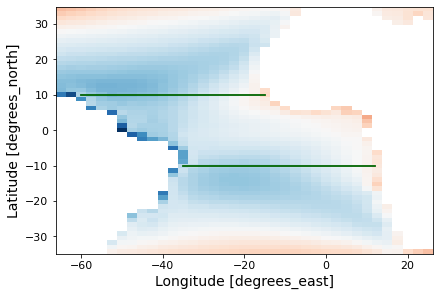

In [151]:
# check mask
fig, axes = plt.subplots(1, 1, constrained_layout=True)

dsTAUUsel_masked.mean(dim=['time','ensemble']).plot(x='lon',
        y='lat',
        cmap='RdBu_r',
       add_colorbar=False)

lat_line = np.linspace(-60, -15, 37)
lon_line = np.full_like(lat_line, 10)
axes.plot(lat_line,lon_line, color='darkgreen',lw=1.8, zorder=120)

lat_line = np.linspace(-35, 12, 37)
lon_line = np.full_like(lat_line, -10)
axes.plot(lat_line,lon_line, color='darkgreen',lw=1.8, zorder=120)

In [152]:
# Constants for Ekman
rho = 1025  # Density of seawater in kg/m^3
omega = 7.2921e-5  # Earth's angular velocity in rad/s

def coriolis_parameter(latitude):
    """Calculate the Coriolis parameter for a given latitude."""
    return 2 * omega * np.sin(np.radians(latitude))

def ekman_transport(tau, f):
    """Calculate the Ekman transport."""
    return - tau / (rho * f)

earth_radius = 6371000  # Earth's radius in meters

def distance_per_longitude_degree(latitude):
    """Calculate the distance in meters for one degree of longitude at a given latitude."""
    return np.pi * earth_radius * np.cos(np.radians(latitude)) / 180

In [153]:
# 10N
closest_lat = dsTAUUsel_masked.lat[np.abs(dsTAUUsel_masked.lat - 10).argmin()].item()
#print(closest_lat)
tauu10N = dsTAUUsel_masked.sel(lat = closest_lat,lon = slice(-60,-15)) 
 
fN = coriolis_parameter(tauu10N.lat.values)
m10N = ekman_transport(tauu10N, fN)

d10N = distance_per_longitude_degree(tauu10N.lat.values) # 1 deg long (at 10N lat) in meters 
dlon = tauu10N.lon.diff('lon') # long distance in degrees
dlon_to_meters = dlon*d10N # long distance in meters 

# Integrate transport along the longtude from 60 to 15W
EK10Nsv = (m10N.sel(lon=slice(-60,-15)).sum('lon') * dlon_to_meters[0])/1e6 # ekman merid transp in Sv

# Compute anomaly
anomEKn = EK10Nsv.groupby('time.month') - EK10Nsv.sel(time=slice_clim).groupby('time.month').mean('time')

In [154]:
# 10S
closest_lat = dsTAUUsel_masked.lat[np.abs(dsTAUUsel_masked.lat - (-10)).argmin()].item()
tauu10S = dsTAUUsel_masked.sel(lat = closest_lat,lon = slice(-35,12))

f = coriolis_parameter(tauu10S.lat.values)
m10S = ekman_transport(tauu10S, f)

d10S = distance_per_longitude_degree(tauu10S.lat.values) # 1 deg long (at 10N lat) in meters 
dlon = tauu10S.lon.diff('lon') # long distance in degrees
dlon_to_meters = dlon*d10S # long distance in meters 

# Integrate transport along the longtude from 60 to 15W
EK10Ssv = (m10S.sel(lon=slice(-35,12)).sum('lon') * dlon_to_meters[0])/1e6 # ekman merid transp in Sv

# Invert the EK transport in the south (both are positive pointing to south)
EK10SsvINV = EK10Ssv*-1 

# Compute anomaly
anomEKs = EK10Ssv.groupby('time.month') - EK10Ssv.sel(time=slice_clim).groupby('time.month').mean('time')
anomEKsINV = EK10SsvINV.groupby('time.month') - EK10SsvINV.sel(time=slice_clim).groupby('time.month').mean('time')

In [155]:
# Poleward Ekman transport ANOMALY 10yr running avg
# 10N
anomEKn_smooth = anomEKn.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # IPSL
anomEKn_smooth2 = anomEKn_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomEKn_std = anomEKn_smooth.mean('ensemble').std('time')
anomEKn_avg = anomEKn_smooth.mean('ensemble').mean('time')

# 10S
anomEKs_smooth = anomEKsINV.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # IPSL
anomEKs_smooth2 = anomEKs_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomEKsINV_std =  anomEKs_smooth.mean('ensemble').std('time')
anomEKsINV_avg =  anomEKs_smooth.mean('ensemble').mean('time')

In [156]:
## trends 1850-2015
#EKslopeN, EKintercept, EKr_squared, EKp_value, EKtrend_lineN = calculate_linear_trend(anomEKn_smooth2.mean('ensemble').sel(time=slice(1850,2015)).dropna(dim='time') )
#EKslopeS, EKintercept, EKr_squared, EKp_value, EKtrend_lineS = calculate_linear_trend(anomEKs_smooth2.mean('ensemble').sel(time=slice(1850,2015)).dropna(dim='time') )

#val1850 = EKtrend_lineN.sel(time=1850, method="nearest")
#val2015 = EKtrend_lineN.sel(time=2015, method="nearest")
#print(f"EKn Value 1850: {val1850.values}, value 2015 {val2015.values}")
#delta = val2015 - val1850
#print(f"Absolute change in EKn from 1850 to 2015: {delta.values}")

#val1850 = EKtrend_lineS.sel(time=1850, method="nearest")
#val2015 = EKtrend_lineS.sel(time=2015, method="nearest")
#print(f"EKs Value 1850: {val1850.values}, value 2015 {val2015.values}")
#delta = val2015 - val1850
#print(f"Absolute change in EKs from 1850 to 2015: {delta.values}")

## * Standardize Ekman and thermocline transports

In [157]:
# Ekman 
anomEKn_smooth2_stdz = standardize(anomEKn_smooth2)
anomEKs_smooth2_stdz = standardize(anomEKs_smooth2)
# WB thermocline
anomVN_WBCtransp_mldTHCD_smooth2_stdz = standardize(anomVN_WBCtransp_mldTHCD_inv_smooth2)
anomVS_WBCtransp_mldTHCD_smooth2_stdz = standardize(anomVS_WBCtransp_mldTHCD_smooth2)

In [158]:
# trends 1850-2015 (stdz)
slopeWBn, intercept, r_squared, p_value, trend_lineWBn = calculate_linear_trend(anomVN_WBCtransp_mldTHCD_smooth2_stdz.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )
slopeWBs, intercept, r_squared, p_value, trend_lineWBs = calculate_linear_trend(anomVS_WBCtransp_mldTHCD_smooth2_stdz.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )
slopeEKn, intercept, r_squared, p_value, trend_lineEKn = calculate_linear_trend(anomEKn_smooth2_stdz.mean('ensemble').sel(time=slice(1850,2015)).dropna(dim='time') )
slopeEKs, intercept, r_squared, p_value, trend_lineEKs = calculate_linear_trend(anomEKs_smooth2_stdz.mean('ensemble').sel(time=slice(1850,2015)).dropna(dim='time') )

Linear trend: slope = 0.005 (units/year), intercept = -8.979
R-squared: 0.326, p-value: 1.12e-15
Linear trend: slope = 0.009 (units/year), intercept = -16.206
R-squared: 0.660, p-value: 4.82e-40
Linear trend: slope = -0.011 (units/year), intercept = 21.747
R-squared: 0.916, p-value: 1.35e-89
Linear trend: slope = 0.005 (units/year), intercept = -9.983
R-squared: 0.475, p-value: 1.49e-24


## * Lag correlations Ekman vs. WB (stdz)

In [159]:
# select pre-ind (500-1850)
# Ekman 
PreInd_anomEKn_smooth = anomEKn_smooth2.sel(time=slice('0500','1850')).dropna(dim='time')
PreInd_anomEKs_smooth = anomEKs_smooth2.sel(time=slice('0500','1850')).dropna(dim='time')
# WB thermocline
PreInd_anomVN_WBC_smooth = anomVN_WBCtransp_mldTHCD_inv_smooth2.sel(time=slice('0500','1850')).dropna(dim='time')
PreInd_anomVS_WBC_smooth = anomVS_WBCtransp_mldTHCD_smooth2.sel(time=slice('0500','1850')).dropna(dim='time')

# full past2k
# Ekman 
anomEKn_smooth = anomEKn_smooth2.dropna(dim='time')
anomEKs_smooth = anomEKs_smooth2.dropna(dim='time')
# WB thermocline
anomVN_WBC_smooth = anomVN_WBCtransp_mldTHCD_inv_smooth2.dropna(dim='time')
anomVS_WBC_smooth = anomVS_WBCtransp_mldTHCD_smooth2.dropna(dim='time')

In [160]:
# Define the variables
variables1 = {
    "10N Ekman pre-ind": PreInd_anomEKn_smooth.mean('ensemble'),
    "10S Ekman pre-ind": PreInd_anomEKs_smooth.mean('ensemble'),
    "10N Ekman": anomEKn_smooth.mean('ensemble'),
    "10S Ekman": anomEKs_smooth.mean('ensemble'),
}

variables2 = {
    "10N WB pre-ind": PreInd_anomVN_WBC_smooth.mean('record'),
    "10S WB pre-ind": PreInd_anomVS_WBC_smooth.mean('record'),
    "10N WB": anomVN_WBC_smooth.mean('record'),
    "10S WB": anomVS_WBC_smooth.mean('record'),
}

# Specific pairs to analyze
specific_pairs = [("10N Ekman", "10N WB", "10\N{DEGREE SIGN}N past2k",'#166534'), 
                  ("10N Ekman pre-ind", "10N WB pre-ind", "10\N{DEGREE SIGN}N pre-ind",'#9BCF9B'),
                  ("10S Ekman", "10S WB", "10\N{DEGREE SIGN}S past2k",'#6B21A8'),
                  ("10S Ekman pre-ind", "10S WB pre-ind", "10\N{DEGREE SIGN}S pre-ind",'#C084FC')]

# Parameters for lag range
max_lag_years = 50

# Initialize results storage
results = []

## Figure

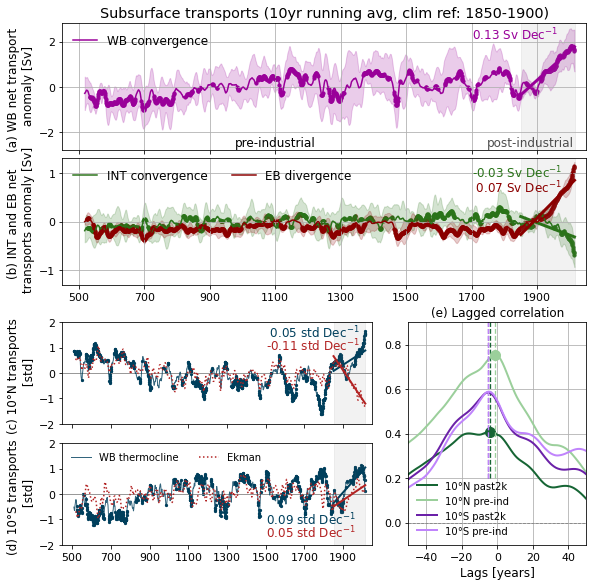

In [162]:
colorWBC = '#003f5c'

plt.rcParams.update({"font.size": 12,"xtick.labelsize": 11,"ytick.labelsize": 11,})
fig = plt.figure(figsize=(8, 8), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.001, h_pad=0.03)
gs = fig.add_gridspec(nrows=4,ncols=3,height_ratios=[1, 1, 0.8, 0.8], width_ratios=[1, 1, 1.3])  

### FIRST SUBPLOT -- WB CONVERGENCE
ax_WBconv = fig.add_subplot(gs[0, :])      # row 0, all columns
ax_WBconv.set_title('Subsurface transports (10yr running avg, clim ref: '+clim_ref+')') 
ax_WBconv.set_ylabel('(a) WB net transport \n anomaly [Sv]')
ax_WBconv.grid()
x,y = stippling_signal_agreement(anomTHCD_WB_conv_smooth2,80)
ax_WBconv.fill_between(range(500,2015), anomWB_conf.lb, anomWB_conf.ub, color='#990099', alpha=.2)
ax_WBconv.plot(range(500,2015), anomTHCD_WB_conv_smooth2.mean('record'),c='#990099',label='WB convergence')
ax_WBconv.scatter(x[1:],y[1:], color='#990099', marker='o', s=10, edgecolors='#990099') # stippling where the anomaly agrees on signal
ax_WBconv.plot(range(1850,2015), trend_line_WBconv, color='#990099',lw=3)
ax_WBconv.text(1700, 2.1, f"{round(slope_WBconv*10, 2)} Sv Dec$^{{-1}}$", color='#990099', fontsize=12)

ax_WBconv.legend(frameon=False, loc='upper left', ncol=2)
ax_WBconv.set_ylim(-2.8,2.8)
ax_WBconv.text(1100,-2.6,'pre-industrial',color='k',ha='center')
ax_WBconv.axvspan(1852, 2015, alpha=0.1, color='gray')
ax_WBconv.text(1880,-2.6,'post-industrial',color='#4D4D4D',ha='center')
plt.setp(ax_WBconv.get_xticklabels(), visible=False)



### SECOND SUBPLOT -- INT AND EB 
ax_INTeEB = fig.add_subplot(gs[1, :], sharex=ax_WBconv)      # row 1, all columns
ax_INTeEB.set_ylabel('(b) INT and EB net \n transports anomaly [Sv]')
ax_INTeEB.grid()
# INT convergence
x,y = stippling_signal_agreement(anomTHCD_INT_conv_smooth2,80)
ax_INTeEB.fill_between(range(500,2015), anomINT_conf.lb, anomINT_conf.ub, color='#2A7319', alpha=.2)
ax_INTeEB.plot(range(500,2015), anomTHCD_INT_conv_smooth2.mean('record'),c='#2A7319',label='INT convergence')
ax_INTeEB.scatter(x[1:],y[1:], color='#2A7319', marker='o', s=10, edgecolors='#2A7319') # stippling where the anomaly agrees on signal
ax_INTeEB.plot(range(1850,2015), trend_line_INTconv, color='#2A7319',lw=3)
ax_INTeEB.text(1700, 0.9, f"{round(slope_INTconv*10, 2)} Sv Dec$^{{-1}}$", color='#2A7319', fontsize=12)
# EB divergence 
x,y = stippling_signal_agreement(anomTHCD_EB_div_smooth2,80)
ax_INTeEB.fill_between(range(500,2015), anomEB_conf.lb, anomEB_conf.ub, color='darkred', alpha=.2)
ax_INTeEB.plot(range(500,2015), anomTHCD_EB_div_smooth2.mean('record'),c='darkred',label='EB divergence')
ax_INTeEB.scatter(x[1:],y[1:], color='darkred', marker='o', s=10, edgecolors='darkred') # stippling where the anomaly agrees on signal
ax_INTeEB.plot(range(1850,2015), trend_line_EBdiv, color='darkred',lw=3)
ax_INTeEB.text(1700, 0.6, f" {round(slope_EBdiv*10, 2)} Sv Dec$^{{-1}}$", color='darkred', fontsize=12)

ax_INTeEB.legend(frameon=False, loc='upper left', ncol=2)
ax_INTeEB.set_ylim(-1.3,1.3)
ax_INTeEB.set_xlim(450,2050)
ax_INTeEB.set_xticks(np.arange(500,2014,200))
ax_INTeEB.axvspan(1852, 2015, alpha=0.1, color='gray')



#### THIRD SUBPLOT -- NORTH EKMAN AND THERMOCLINE
ax_nWBnEK = fig.add_subplot(gs[2, :2])     # row 2, columns 0–1
ax_nWBnEK.set_ylabel('(c) 10\N{DEGREE SIGN}N transports \n [std]')
ax_nWBnEK.axhline(y=0, c='gray', lw=.8)
# WB thermocline transport 
x,y = stippling_signal_agreement(anomVN_WBCtransp_mldTHCD_smooth2_stdz,80)
ax_nWBnEK.plot(range(500,2015), anomVN_WBCtransp_mldTHCD_smooth2_stdz.mean('record'),c=colorWBC,lw=1, alpha=.8, label='WB thermocline')
ax_nWBnEK.scatter(x[1:],y[1:], color=colorWBC, marker='o', s=5, edgecolors=colorWBC) # stippling where the anomaly agrees on signal
ax_nWBnEK.plot(range(1850,2015), trend_lineWBn, color=colorWBC,lw=2)
ax_nWBnEK.text(1500, 1.4, f" {round(slopeWBn*10, 2)} std Dec$^{{-1}}$", color=colorWBC, fontsize=12)
# Ekman north
ax_nWBnEK.plot(range(500,2015), anomEKn_smooth2_stdz.mean('ensemble'),c='firebrick', ls=':', label='Ekman')
ax_nWBnEK.plot(range(1850,2015), trend_lineEKn, color='firebrick',lw=2)
ax_nWBnEK.text(1500, 0.9, f"{round(slopeEKn*10, 2)} std Dec$^{{-1}}$", color='firebrick', fontsize=12)

ax_nWBnEK.set_ylim(-2,2)
ax_nWBnEK.axvspan(1852, 2015, alpha=0.1, color='gray')
plt.setp(ax_nWBnEK.get_xticklabels(), visible=False)


#### FOURTH SUBPLOT -- SOUTH EKMAN AND THERMOCLINE
ax_sWBsEK = fig.add_subplot(gs[3, :2], sharex=ax_nWBnEK)     # row 3, columns 0–1
ax_sWBsEK.set_ylabel('(d) 10\N{DEGREE SIGN}S transports \n [std]')
ax_sWBsEK.axhline(y=0, c='gray', lw=.8)
# WB thermocline transport
x,y = stippling_signal_agreement(anomVS_WBCtransp_mldTHCD_smooth2_stdz,80)
ax_sWBsEK.plot(range(500,2015), anomVS_WBCtransp_mldTHCD_smooth2_stdz.mean('record'),c=colorWBC, lw=1, alpha=.8, label='WB thermocline')
ax_sWBsEK.scatter(x[1:],y[1:], color=colorWBC, marker='o', s=5, edgecolors=colorWBC) # stippling where the anomaly agrees on signal
ax_sWBsEK.plot(range(1850,2015), trend_lineWBs, color=colorWBC,lw=2)
ax_sWBsEK.text(1500, -1.2, f"{round(slopeWBs*10, 2)} std Dec$^{{-1}}$", color=colorWBC, fontsize=12)
# Ekman south
ax_sWBsEK.plot(range(500,2015), anomEKs_smooth2_stdz.mean('ensemble'),c='firebrick',ls=':', label='Ekman')
ax_sWBsEK.plot(range(1850,2015), trend_lineEKs, color='firebrick',lw=2)
ax_sWBsEK.text(1500, -1.7, f"{round(slopeEKs*10, 2)} std Dec$^{{-1}}$", color='firebrick', fontsize=12)

ax_sWBsEK.legend(frameon=False, loc='upper left', ncol=2, fontsize=10)
ax_sWBsEK.axvspan(1852, 2015, alpha=0.1, color='gray')
ax_sWBsEK.set_ylim(-2,2)
ax_sWBsEK.set_xlim(450,2050)
ax_sWBsEK.set_xticks(np.arange(500,2014,200))

#### FIFTH SUBPLOT -- CORRELATION EKMAN AND THERMOCLINE TRANSPORTS
ax_corr = fig.add_subplot(gs[2:4, 2])      # rows 2–3, column 2
for i, (var1_name, var2_name, name_label, cor) in enumerate(specific_pairs):
    var1_data = variables1[var1_name]
    var2_data = variables2[var2_name]
    # Calculate lags and correlation
    all_lags = signal.correlation_lags(len(var1_data), len(var2_data))
    lags = all_lags[(all_lags >= -max_lag_years) & (all_lags <= max_lag_years)]
    corrs, p_values = zip(*[crosscorr_stdz(var1_data, var2_data, lag=lag) for lag in lags])
    # Plot lag vs correlation on ax_corr
    line, = ax_corr.plot(lags, corrs,linestyle='-',lw=2,label=name_label,color=cor)
    # Max correlation
    max_idx = np.argmax(np.abs(corrs))
    max_corr = corrs[max_idx]
    max_p_value = p_values[max_idx]
    max_lag = lags[max_idx]
    # Correlation at zero lag
    zeroLag_idx = np.argmax(lags == 0)
    zeroLag_corr = corrs[zeroLag_idx]
    zeroLag_p_value = p_values[zeroLag_idx]
    # Vertical line at max lag
    ax_corr.axvline(x=max_lag, ymin=0.3,ymax=1,color=line.get_color(),linestyle='--',linewidth=1.3)
    # Asterisk / marker at max correlation for first two pairs only
    if i < 2:
        ax_corr.plot(max_lag,max_corr,'o',markersize=10,color=line.get_color())
    # Store results
    results.append({
        "Var1": var1_name,
        "Var2": var2_name,
        "MaxCorr": max_corr,
        "MaxLag": max_lag,
        "PValue": max_p_value,
        "CorrLagZero": zeroLag_corr,
        "PValueLagZero": zeroLag_p_value,
    })
# To use outside if needed
results_df = pd.DataFrame(results)

ax_corr.set_xlabel('Lags [years]')
ax_corr.set_xlim(-50, 50)
ax_corr.set_ylim(-0.1, 0.9)
ax_corr.set_title('(e) Lagged correlation',fontsize=12)  # or whatever panel label you want
ax_corr.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_corr.legend(frameon=False, ncol=1, loc='lower left',fontsize=10)
ax_corr.grid(True)

fig.savefig(PathFigures+'/figure_time_series_corr_WB_INT_EB_ekman.png', format='png', bbox_inches='tight', dpi=300,  facecolor='white')
